# Notebook 2: Train the ranker with MLflow tracking

Train an XGBoost binary classifier on `shared/pipes_blended.parquet`.
Log everything to the AIE-managed MLflow tracking server (params, metrics,
model artifact, feature-importance chart). Emit a portable model artifact for the
BentoML packaging notebook to consume.

**What lands in MLflow**

- Params: hyperparameters + row/column counts
- Metrics: ROC-AUC, PR-AUC, precision/recall/F1 at 0.5 threshold
- Artifacts: `feature_importance.png`, the XGBoost model itself (via `mlflow.xgboost`)
- Tags: feature list, provenance link, positive-class rate

**Demo framing reminder**: lead with feature importance in the customer meeting,
not AUC. Real AUC comes from the customer's own CCTV outcomes at retrain time.

In [ ]:
!pip install --user xgboost==2.1.2

In [1]:
import os
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import xgboost as xgb
import mlflow
import mlflow.xgboost
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    roc_auc_score, average_precision_score, confusion_matrix, classification_report,
)

SHARED_DIR = Path(os.environ.get("SHARED_DIR", "shared"))
MODEL_PATH = SHARED_DIR / "ranker_v1.json"
IMPORTANCE_PATH = SHARED_DIR / "feature_importance.png"

RANDOM_STATE = 42
EXPERIMENT_NAME = "water-utility-tree-root-ranker"

## 1. Configure MLflow

On AIE 1.10.1, the MLflow tracking server is pre-deployed cluster-wide and its URI
is injected into notebook pods via the `MLFLOW_TRACKING_URI` environment variable.
If your kernel doesn't have it, uncomment the manual override.

In [2]:
tracking_uri = os.environ.get("MLFLOW_TRACKING_URI")
if not tracking_uri:
    # Manual override — set to your cluster's MLflow server URL if the env var is missing
    # tracking_uri = "http://mlflow-tracking.mlflow.svc.cluster.local:5000"
    raise RuntimeError(
        "MLFLOW_TRACKING_URI not set — is this notebook running on AIE with MLflow enabled?"
    )

mlflow.set_tracking_uri(tracking_uri)
mlflow.set_experiment(EXPERIMENT_NAME)
print(f"MLflow tracking URI : {tracking_uri}")
print(f"MLflow experiment   : {EXPERIMENT_NAME}")

2026/08/10 01:48:00 INFO mlflow.tracking.fluent: Experiment with name 'water-utility-tree-root-ranker' does not exist. Creating a new experiment.


MLflow tracking URI : http://mlflow.mlflow.svc.cluster.local:5000
MLflow experiment   : water-utility-tree-root-ranker


## 2. Load

In [3]:
df = pd.read_parquet(SHARED_DIR / "pipes_blended.parquet")
print(f"loaded {len(df)} rows, positive class = {df['has_root_incident_5y'].mean():.1%}")
df.head(3)

loaded 2000 rows, positive class = 11.1%


,pipe_id,district_code,material,lat,lon,year_installed,dominant_species,soil_class,traffic_load_class,age_years,material_ordinal,diameter_mm,slope_pct,depth_m,nearest_tree_dist_m,trees_within_15m,dominant_species_riskscore,historical_incident_count,has_root_incident_5y
0,P-000000,WEST,CI,34.066867,-118.297693,1989,European nettle tree,CLAY,LOW,37,3,200,1.00,2.12,100.00,0,0.5,0,0
1,P-000001,WEST,CI,34.074903,-118.287005,2010,Kanooka,LOAM,HIGH,16,3,150,2.47,1.29,31.46,0,0.5,0,0
2,P-000002,NORTH,VC,34.076943,-118.248175,1943,Chinaberry Tree,CLAY,MED,83,4,150,2.30,2.18,923.75,0,0.5,1,0


## 3. Feature selection

In [4]:
FEATURES = [
    "age_years",
    "material_ordinal",
    "diameter_mm",
    "slope_pct",
    "depth_m",
    "nearest_tree_dist_m",
    "trees_within_15m",
    "dominant_species_riskscore",
    "historical_incident_count",
]
TARGET = "has_root_incident_5y"

X = df[FEATURES].astype(float)
y = df[TARGET].astype(int)
print(f"X shape: {X.shape}, positive rate: {y.mean():.1%}")

X shape: (2000, 9), positive rate: 11.1%


## 4. Train with MLflow autolog

scale_pos_weight = 8.04


2026/08/10 01:49:29 WARNING mlflow.utils.autologging_utils: MLflow autologging encountered a warning: "/home/daniel-cao/.local/lib/python3.11/site-packages/xgboost/core.py:158: UserWarning: [01:49:29] WARNING: /workspace/src/c_api/c_api.cc:1374: Saving model in the UBJSON format as default.  You can use file extension: `json`, `ubj` or `deprecated` to choose between formats."


ROC-AUC : 0.828
PR-AUC  : 0.348
Confusion matrix:
[[327  29]
 [ 26  18]]

              precision    recall  f1-score   support

 no_incident       0.93      0.92      0.92       356
    incident       0.38      0.41      0.40        44

    accuracy                           0.86       400
   macro avg       0.65      0.66      0.66       400
weighted avg       0.87      0.86      0.86       400



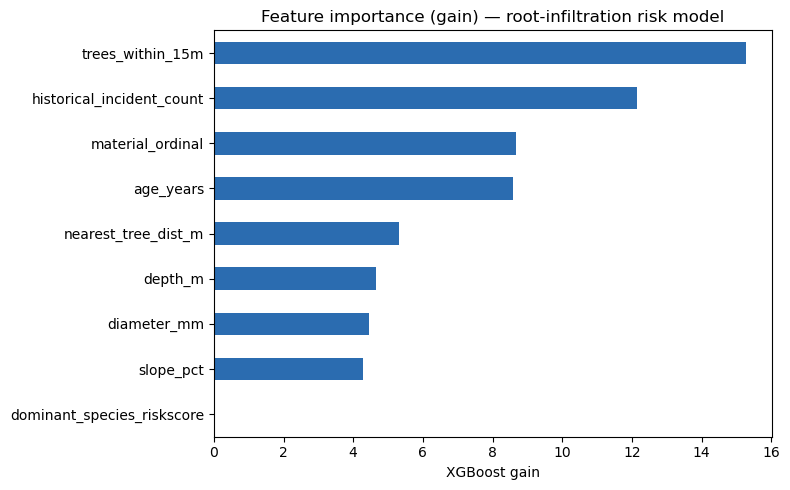

top 5 features by gain: ['trees_within_15m', 'historical_incident_count', 'material_ordinal', 'age_years', 'nearest_tree_dist_m']
wrote shared/ranker_v1.json (491.4 KB)

MLflow run ID: 9ba4509fe6a2463bb86b0767fcb65539
View in UI: http://mlflow.mlflow.svc.cluster.local:5000/#/experiments/16/runs/9ba4509fe6a2463bb86b0767fcb65539
🏃 View run xgb-v1-baseline at: http://mlflow.mlflow.svc.cluster.local:5000/#/experiments/16/runs/9ba4509fe6a2463bb86b0767fcb65539
🧪 View experiment at: http://mlflow.mlflow.svc.cluster.local:5000/#/experiments/16


In [5]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, stratify=y, random_state=RANDOM_STATE
)

pos_weight = (y_train == 0).sum() / max((y_train == 1).sum(), 1)
print(f"scale_pos_weight = {pos_weight:.2f}")

# xgboost autolog captures params, training metrics, and the model artifact
mlflow.xgboost.autolog(log_model_signatures=True, log_input_examples=False)

with mlflow.start_run(run_name="xgb-v1-baseline") as run:
    # Tags visible in MLflow UI
    mlflow.set_tags({
        "use_case": "tree-root-infiltration-risk",
        "feature_set": ",".join(FEATURES),
        "target": TARGET,
        "provenance": "LA pipes + Melbourne trees + CA SSO (mechanically translated)",
        "pos_rate": f"{y.mean():.3f}",
    })

    model = xgb.XGBClassifier(
        n_estimators=200,
        max_depth=5,
        learning_rate=0.08,
        subsample=0.9,
        colsample_bytree=0.9,
        scale_pos_weight=pos_weight,
        eval_metric="auc",
        random_state=RANDOM_STATE,
        tree_method="hist",
    )
    model.fit(X_train, y_train, eval_set=[(X_test, y_test)], verbose=False)

    # Holdout metrics
    proba = model.predict_proba(X_test)[:, 1]
    pred = (proba >= 0.5).astype(int)

    auc = roc_auc_score(y_test, proba)
    pr_auc = average_precision_score(y_test, proba)
    cm = confusion_matrix(y_test, pred)

    mlflow.log_metrics({
        "holdout_roc_auc": auc,
        "holdout_pr_auc": pr_auc,
        "holdout_tp": int(cm[1, 1]),
        "holdout_fp": int(cm[0, 1]),
        "holdout_tn": int(cm[0, 0]),
        "holdout_fn": int(cm[1, 0]),
    })

    print(f"ROC-AUC : {auc:.3f}")
    print(f"PR-AUC  : {pr_auc:.3f}")
    print(f"Confusion matrix:\n{cm}")
    print()
    print(classification_report(y_test, pred, target_names=["no_incident", "incident"]))
    assert auc >= 0.70, f"AUC {auc:.3f} below TC-U2-01 pass criterion of 0.70"

    # Feature importance chart — the demo headline artifact
    booster = model.get_booster()
    booster.feature_names = FEATURES
    imp = booster.get_score(importance_type="gain")
    imp_series = pd.Series(imp).reindex(FEATURES).fillna(0).sort_values()

    fig, ax = plt.subplots(figsize=(8, 5))
    imp_series.plot.barh(ax=ax, color="#2b6cb0")
    ax.set_title("Feature importance (gain) — root-infiltration risk model")
    ax.set_xlabel("XGBoost gain")
    ax.set_ylabel("")
    plt.tight_layout()
    plt.savefig(IMPORTANCE_PATH, dpi=140, bbox_inches="tight")
    plt.show()
    mlflow.log_artifact(str(IMPORTANCE_PATH))

    top5 = list(imp_series.sort_values(ascending=False).head(5).index)
    print(f"top 5 features by gain: {top5}")
    mlflow.set_tag("top5_features", ",".join(top5))

    # Persist artifact locally too so the Bento packaging notebook can pick it up
    booster.save_model(str(MODEL_PATH))
    size_kb = MODEL_PATH.stat().st_size / 1024
    print(f"wrote {MODEL_PATH} ({size_kb:.1f} KB)")

    run_id = run.info.run_id
    print(f"\nMLflow run ID: {run_id}")
    print(f"View in UI: {tracking_uri}/#/experiments/{run.info.experiment_id}/runs/{run_id}")

## 5. Sanity — reload and predict

In [6]:
b2 = xgb.Booster()
b2.load_model(str(MODEL_PATH))
dmat = xgb.DMatrix(X_test.head(3), feature_names=FEATURES)
print("reloaded model probes:", b2.predict(dmat).round(3).tolist())

reloaded model probes: [0.04100000113248825, 0.03700000047683716, 0.02800000086426735]


## Pass criteria

| Criterion | Value |
|---|---|
| MLflow run recorded in experiment `water-utility-tree-root-ranker` | ✅ |
| Holdout ROC-AUC ≥ 0.70 | asserted above |
| Feature importance PNG logged as run artifact | ✅ |
| Local `ranker_v1.json` written for Bento consumption | ✅ |

**Next**: `02_bento_package.ipynb` picks up `ranker_v1.json`, packages via BentoML,
containerizes, and produces the image tag to register in MLIS UI.